In [2]:
pip install scikit-learn -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install imblearn 

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached sklearn_compat-0.1.3-py3-none-any.whl.metadata (18 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.13.0-py3-none-any.whl (238 kB)
Using cached sklearn_compat-0.1.3-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: pytorch-lightning 1.7.6 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [3]:
conda list

# packages in environment at D:\Anaconda\envs\PODAA:
#
# Name                    Version                   Build  Channel
anyio                     4.8.0              pyhd8ed1ab_0    conda-forge
argon2-cffi               23.1.0             pyhd8ed1ab_1    conda-forge
argon2-cffi-bindings      21.2.0          py312h4389bb4_5    conda-forge
arrow                     1.3.0              pyhd8ed1ab_1    conda-forge
asttokens                 3.0.0              pyhd8ed1ab_1    conda-forge
async-lru                 2.0.4              pyhd8ed1ab_1    conda-forge
attrs                     25.1.0             pyh71513ae_0    conda-forge
babel                     2.17.0             pyhd8ed1ab_0    conda-forge
beautifulsoup4            4.13.3             pyha770c72_0    conda-forge
bleach                    6.2.0              pyh29332c3_4    conda-forge
bleach-with-css           6.2.0                h82add2a_4    conda-forge
boruta                    0.4.3                    pypi_0    pypi
brotli-py

In [4]:
pip install pandas -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install openpyxl -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
conda list

# packages in environment at D:\Anaconda\envs\PODAA:
#
# Name                    Version                   Build  Channel
anyio                     4.8.0              pyhd8ed1ab_0    conda-forge
argon2-cffi               23.1.0             pyhd8ed1ab_1    conda-forge
argon2-cffi-bindings      21.2.0          py312h4389bb4_5    conda-forge
arrow                     1.3.0              pyhd8ed1ab_1    conda-forge
asttokens                 3.0.0              pyhd8ed1ab_1    conda-forge
async-lru                 2.0.4              pyhd8ed1ab_1    conda-forge
attrs                     25.1.0             pyh71513ae_0    conda-forge
babel                     2.17.0             pyhd8ed1ab_0    conda-forge
beautifulsoup4            4.13.3             pyha770c72_0    conda-forge
bleach                    6.2.0              pyh29332c3_4    conda-forge
bleach-with-css           6.2.0                h82add2a_4    conda-forge
boruta                    0.4.3                    pypi_0    pypi
brotli-py

Imported featurewiz_polars 0.3.0. Use the following syntax:
 >> from featurewiz_polars import FeatureWiz, FeatureWiz_Model
    
正在计算主效应SHAP值 (基于X_test)...


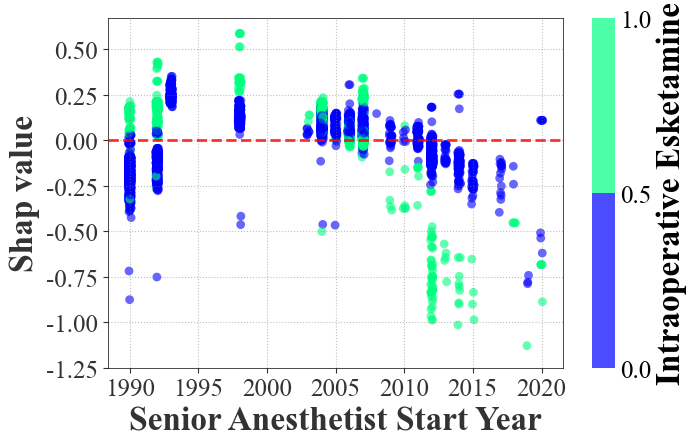

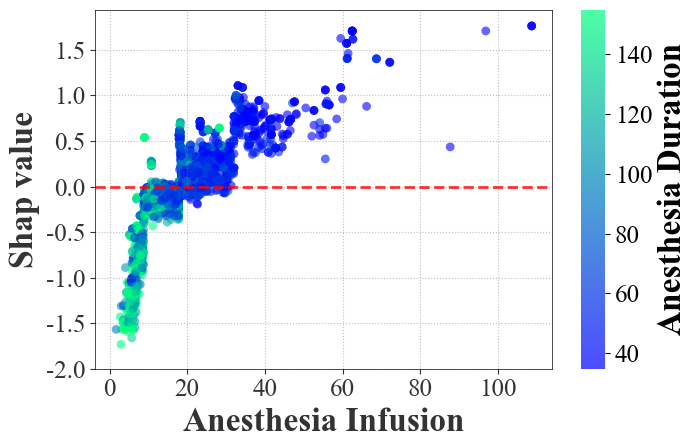

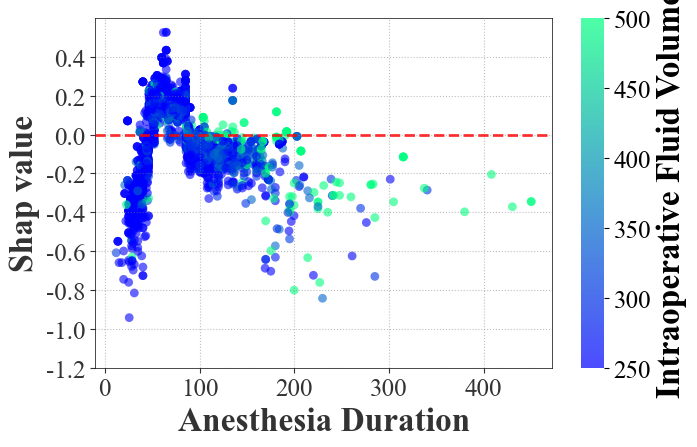

(3677, 52)
主效应SHAP值计算完成。

正在计算SHAP交互效应值 (基于X_test)...


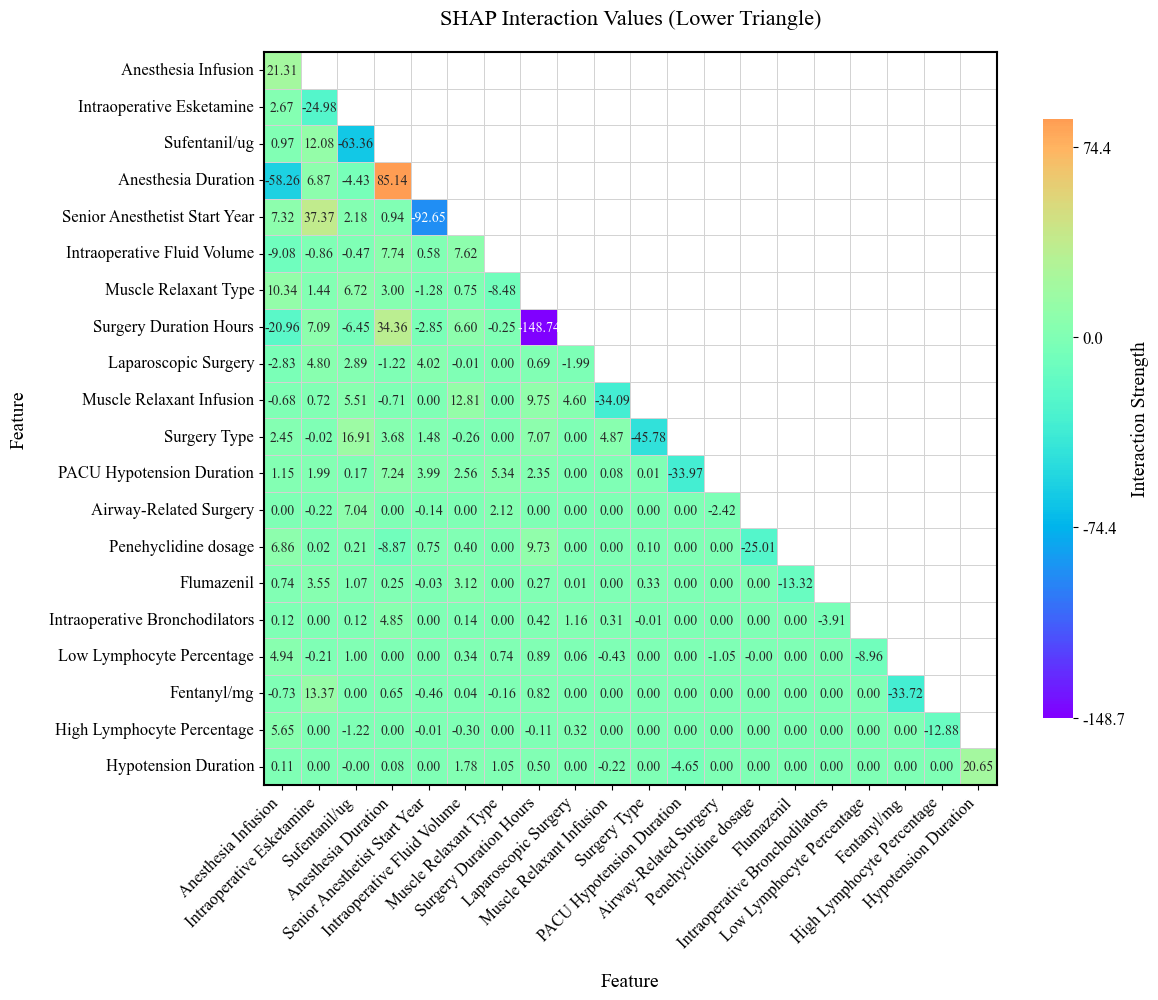

<class 'numpy.ndarray'>


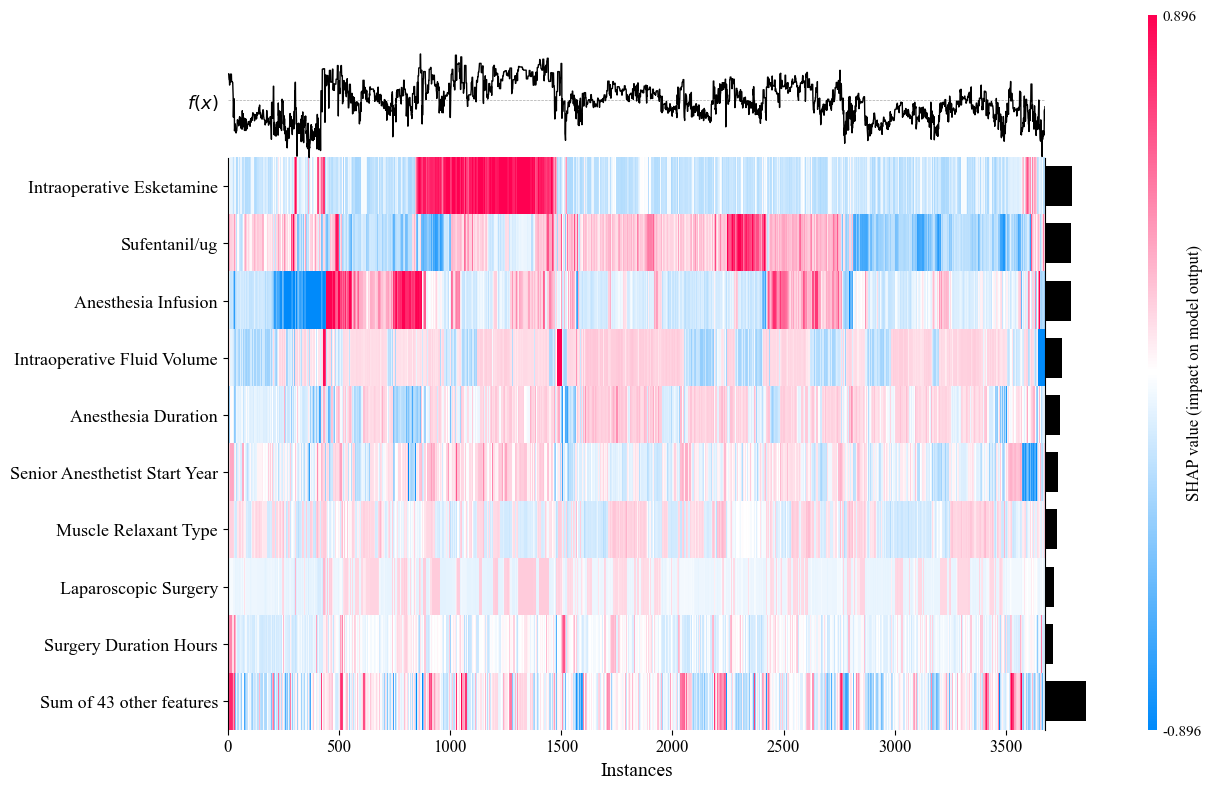

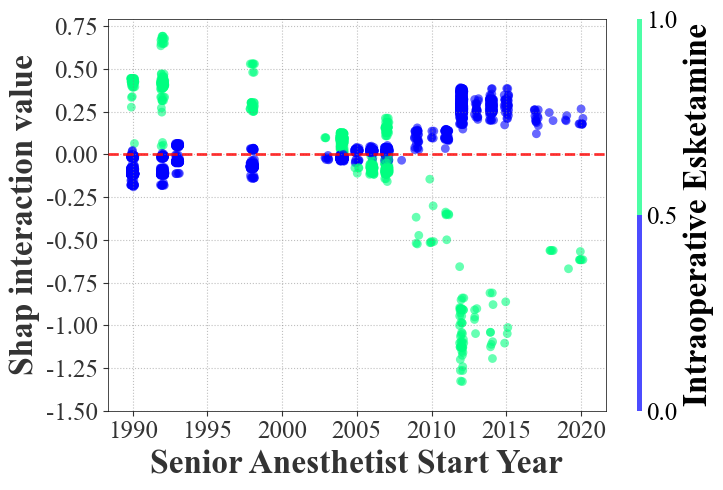

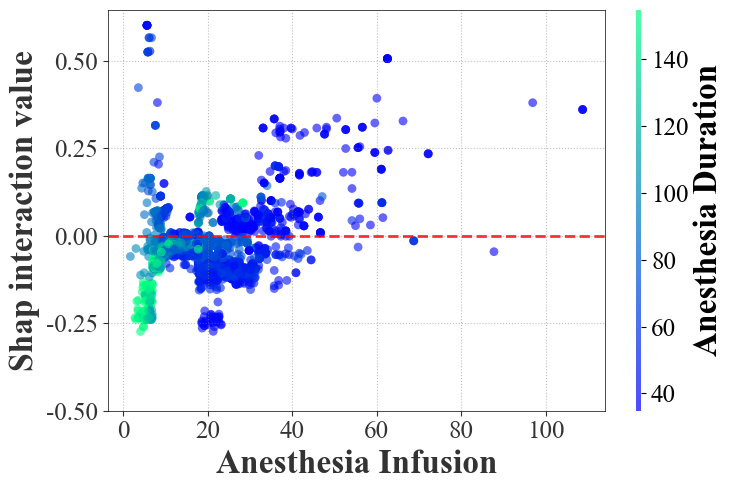

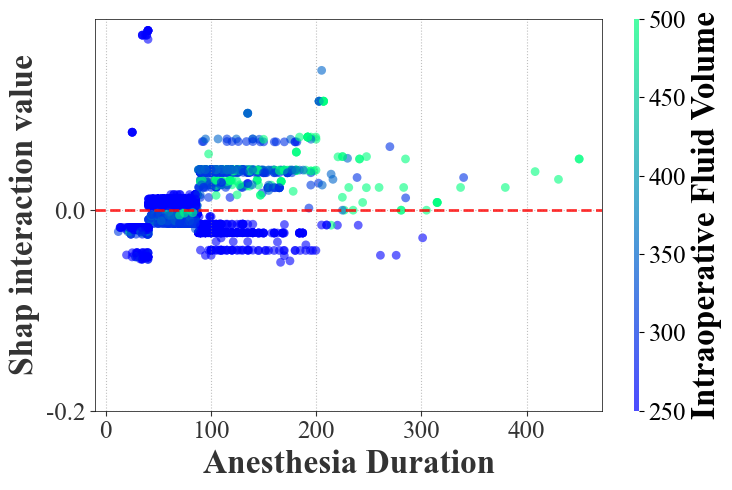

In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

smote = SMOTE(k_neighbors=5)  # 5是邻居数量的一个示例值
# data = pd.read_csv('fin_data/怀化数据_完整_填充缺失值.csv',sep=',')
data = pd.read_csv(r'C:\Users\xiaxq\Desktop\怀化数据_完整_填充缺失值_更新.csv',sep=',')
df = pd.DataFrame(data)

target = 'Delayed Awakening more than 60 mins'
#target = '转出延迟'
#features = df.columns.drop(['苏醒延迟60','转出延迟'])
# features = ['麻醉时长', '麻醉输液mlkgh', '钾离子偏低', '腔镜手术', '肌酐偏高', '钠离子偏高', '麻醉上级工作大于10年1是',
#             '顺阿1维库0', '钙离子偏低','舒芬1阿芬2芬太尼3', '舒芬太尼ugkg', '粒细胞%偏低', '钾离子偏高', '静吸复合麻醉1TIV10', '肌酐偏低', '粒细胞绝对值偏低',
#             '钠离子偏低', '术中输液量ml', '术中艾司氯胺酮1是', '泵注肌松药物1是','眼科手术', '淋巴细胞绝对值偏低', '淋巴细胞%偏低', 
#             '白蛋白偏低', '术前电解质异常', '白蛋白偏高', '气道相关手术', '淋巴细胞绝对值偏高', '淋巴细胞%偏高', '氟马纳洛酮', 
#             '术中支气管扩张药物', '术中有SPO2小于90是1', '术中低血压持续时间min', '是否急诊1是', '术中使用七氟烷', '是否输血', 
#             '术中使用右美1是', '术中1有CO2小于35', '是否复合神经阻滞1是', '术中1有CO2大于45', '是否贫血', 'PACU低血压持续时间', 
#             'PACU再次镇静', '上级开始工作年限', '术中发生低血压1是']

# features = ['Anesthesia Duration', 'Anesthesia Infusion', 'Hypokalemia', 'Laparoscopic Surgery', 'High Creatinine', 
# 'Hypernatremia', 'Senior Anesthetist Experience', 'Muscle Relaxant Type', 
# 'Hypocalcemia', 'Opioid Type', 'Sufentanil', 'Low Neutrophil Percentage', 
# 'Hyperkalemia', 'Combined IV/Inhalation Anesthesia', 'Low Creatinine', 'Low Absolute Neutrophil Count', 
# 'Hyponatremia', 'Intraoperative Fluid Volume', 'Intraoperative Esketamine', 'Muscle Relaxant Infusion', 
# 'Ophthalmic Surgery', 'Low Absolute Lymphocyte Count', 'Low Lymphocyte Percentage', 'Hypoalbuminemia', 
# 'Preoperative Electrolyte Abnormality', 'Hyperalbuminemia', 'Airway-Related Surgery', 'High Absolute Lymphocyte Count', 
# 'High Lymphocyte Percentage', 'Flumazenil', 'Intraoperative Bronchodilators', 'Intraoperative SpO2 less than 90%', 
# 'Hypotension Duration', 'Is Emergency', 'Intraoperative Sevoflurane', 'Blood Transfusion', 
# 'Intraoperative Dexmedetomidine', 'Intraoperative CO2 less than 35', 'Combined Nerve Block', 
# 'Intraoperative CO2 more than 45', 'Anemia', 'PACU Hypotension Duration', 'PACU Resedation', 
# 'Senior Anesthetist Start Year', 'Intraoperative Hypotension','Sufentanil Use','Surgery Duration Hours','Surgery Type']

features = ['Anesthesia Duration', 'Anesthesia Infusion', 'Hypokalemia', 'Laparoscopic Surgery', 'High Creatinine', 
'Hypernatremia', 'Senior Anesthetist Experience', 'Muscle Relaxant Type', 
'Hypocalcemia', 'Opioid Type', 'Low Neutrophil Percentage', 
'Hyperkalemia', 'Combined IV/Inhalation Anesthesia', 'Low Creatinine', 'Low Absolute Neutrophil Count', 
'Hyponatremia', 'Intraoperative Fluid Volume', 'Intraoperative Esketamine', 'Muscle Relaxant Infusion', 
'Ophthalmic Surgery', 'Low Absolute Lymphocyte Count', 'Low Lymphocyte Percentage', 'Hypoalbuminemia', 
'Preoperative Electrolyte Abnormality', 'Hyperalbuminemia', 'Airway-Related Surgery', 'High Absolute Lymphocyte Count', 
'High Lymphocyte Percentage', 'Flumazenil', 'Intraoperative Bronchodilators', 'Intraoperative SpO2 less than 90%', 
'Hypotension Duration', 'Is Emergency', 'Intraoperative Sevoflurane', 'Blood Transfusion', 
'Intraoperative Dexmedetomidine', 'Intraoperative CO2 less than 35', 'Combined Nerve Block', 
'Intraoperative CO2 more than 45', 'Anemia', 'PACU Hypotension Duration', 'PACU Resedation', 
'Senior Anesthetist Start Year', 'Intraoperative Hypotension','Sufentanil Use','Surgery Duration Hours','Surgery Type', 'Penehyclidine dosage', 'Esketamine dosage','Sufentanil/ug', 'Alfentanil/mg', 'Fentanyl/mg']


#去掉'麻醉上级工作时间几年多',

X, y = df[features], df[target]

ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

# selector = SelectKBest(f_classif, k=40)
# X_new = selector.fit_transform(X, y)
# # 选择特征
# selected_features = X.columns[selector.get_support()]

# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(X)

# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 7)
# or_xt = X_test
# or_yt = y_test
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size = 0.3,random_state = 7)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

from PODAA_Model import PODAA
podaa = PODAA(X_train,X_test,y_train,y_test,features)
# podaa = PODAA(X_train,or_xt,y_train,or_yt,features)
# podaa.Kruskal_Wallis('Sufentanil')
# podaa.plot_all_roc_curves_with_ci()
# podaa.plot_all_roc_curves()
podaa.shap_Importance_Features()
#podaa.scatter_plot()

In [2]:
from scipy import stats

feature_name = 'Anesthesia Duration'
df = pd.read_csv(r"C:\Users\xiaxq\Desktop\麻醉苏醒延迟预测模型\fin_data\怀化数据_完整_填充缺失值.csv")

# 2. 提取两组数据
delay_group = df[df['Delayed Awakening more than 60 mins'] == 1][feature_name]  # 苏醒延迟组
no_delay_group = df[df['Delayed Awakening more than 60 mins'] == 0][feature_name]  # 苏醒不延迟组

# 3. 执行Kruskal-Wallis检验
print(no_delay_group)
h_statistic, p_value = stats.kruskal(delay_group, no_delay_group)

# 4. 输出结果
print(f"Kruskal-Wallis检验结果：")
print(f"H统计量 = {h_statistic:.4f}")
print(f"P值 = {p_value:.8f}")

# 5. 判断显著性
alpha = 0.05
if p_value < alpha:
    print(f"P值 < {alpha}，两组在{feature_name}特征上存在显著差异")
else:
    print(f"P值 ≥ {alpha}，两组在{feature_name}特征上无显著差异")

# 6. 可选：计算中位数差异（医学研究常用）
median_diff = delay_group.median() - no_delay_group.median()
print(f"\n中位数差异（延迟组-非延迟组）: {median_diff:.4f}")

0        79.8
1        27.0
3        64.8
5        28.2
6        85.2
        ...  
3234     70.2
3235     64.8
3236     70.2
3237    102.0
3238    112.2
Name: Anesthesia Duration, Length: 2627, dtype: float64
Kruskal-Wallis检验结果：
H统计量 = 31.7177
P值 = 0.00000002
P值 < 0.05，两组在Anesthesia Duration特征上存在显著差异

中位数差异（延迟组-非延迟组）: -10.2000


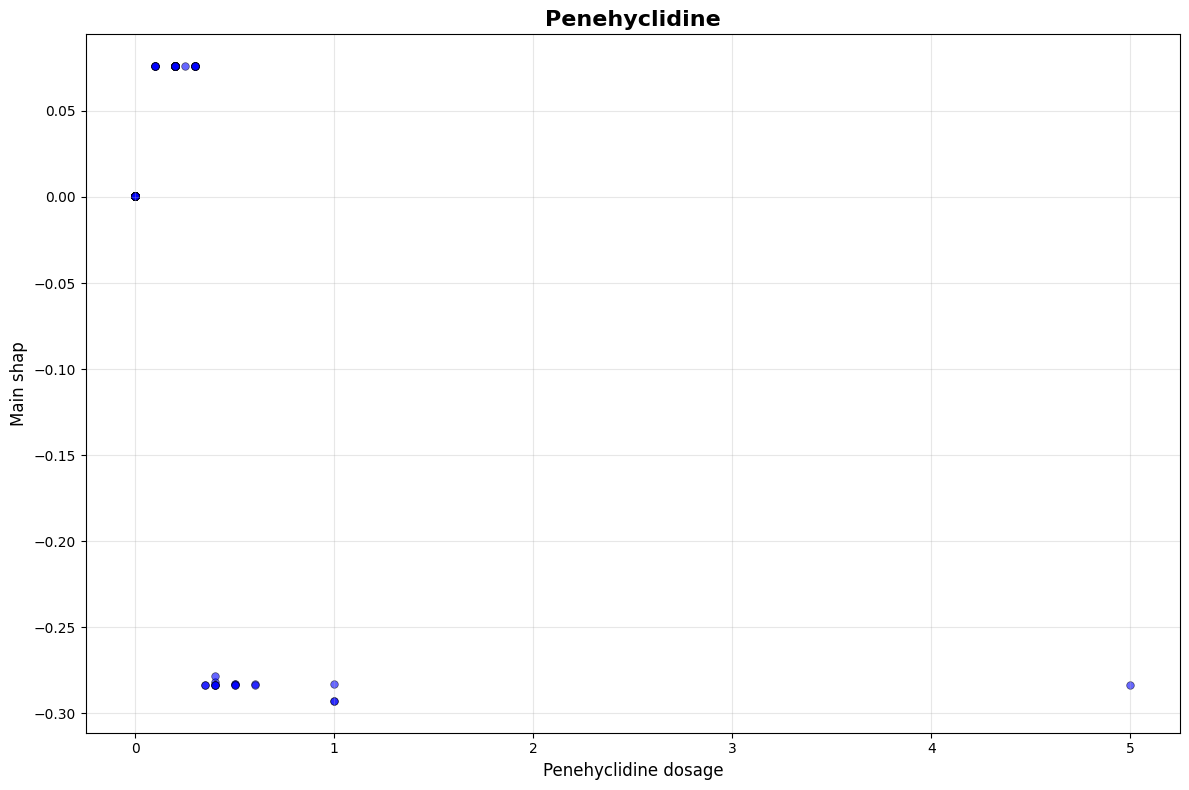

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取Excel文件
df = pd.read_excel(r"C:\Users\xiaxq\Desktop\艾司.xlsx", sheet_name='Sheet4')

# 提取第一列和第二列数据
x = df.iloc[:, 0]  # 第一列作为x轴
y = df.iloc[:, 1]  # 第二列作为y轴

# 创建散点图
plt.figure(figsize=(12, 8))
plt.scatter(x, y, alpha=0.6, s=30, c='blue', edgecolors='black', linewidths=0.5)

# 设置图表标题和坐标轴标签
plt.title('Penehyclidine', fontsize=16, fontweight='bold')
plt.xlabel('Penehyclidine dosage', fontsize=12)
plt.ylabel('Main shap', fontsize=12)

# 添加网格线
plt.grid(True, alpha=0.3)

# 显示图表
plt.tight_layout()
plt.show()


列联表：
Intraoperative Esketamine               0    1
Delayed Awakening more than 60 mins           
0                                    2284  343
1                                     450  162

卡方检验结果：
卡方统计量 = 66.8488
P值 = 0.00000000
自由度 = 1

结论：P值 < 0.05, 两组在 Intraoperative Esketamine特征上分布差异显著（p=0.0000）

效应量（Phi系数） = 0.1437


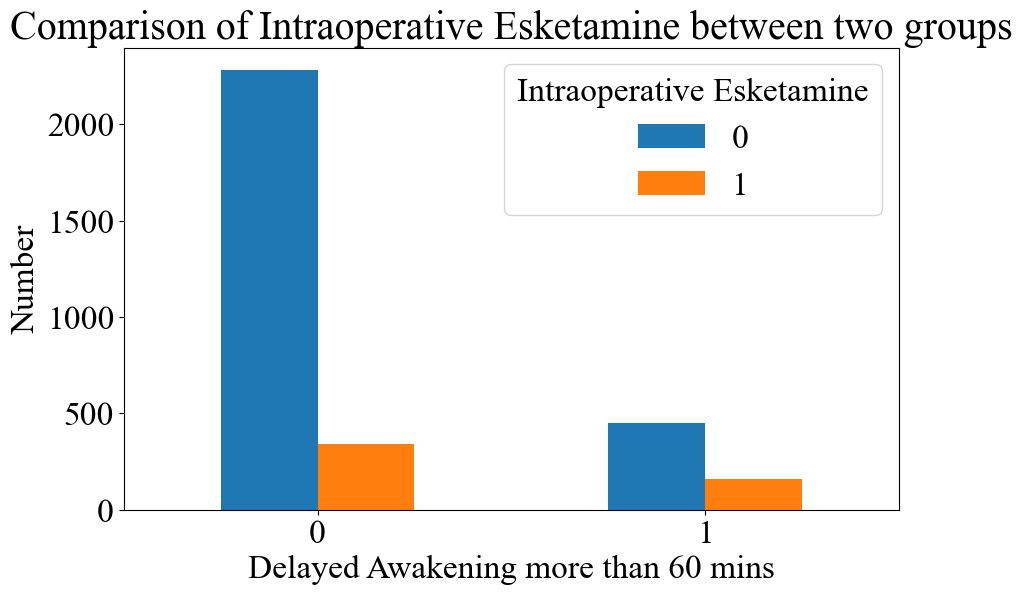

In [3]:
from scipy.stats import chi2_contingency

feature_name = 'Intraoperative Esketamine'
df = pd.read_csv(r"C:\Users\xiaxq\Desktop\麻醉苏醒延迟预测模型\fin_data\怀化数据_完整_填充缺失值.csv")


# 4. 构建列联表（Contingency Table）
contingency_table = pd.crosstab(
    index=df['Delayed Awakening more than 60 mins'],  # 行：分组变量
    columns=df[feature_name],    # 列：目标二分类特征
    margins=False            # 不显示总计行/列
)

# 5. 检查列联表（确保无空单元格）
print("\n列联表：")
print(contingency_table)

# 6. 执行卡方检验
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# 7. 输出结果
print("\n卡方检验结果：")
print(f"卡方统计量 = {chi2:.4f}")
print(f"P值 = {p_value:.8f}")
print(f"自由度 = {dof}")

# 8. 判断显著性
alpha = 0.05
if p_value < alpha:
    print(f"\n结论：P值 < {alpha}, 两组在 {feature_name}特征上分布差异显著（p={p_value:.4f}）")
else:
    print(f"\n结论：P值 ≥ {alpha}，两组在{feature_name}特征上无显著差异（p={p_value:.4f}）")

# 9. 计算效应量（Phi系数或Cramer's V）
n = contingency_table.sum().sum()
phi = np.sqrt(chi2 / n)  # 适用于2x2表
print(f"\n效应量（Phi系数） = {phi:.4f}")

# 10. 可视化（可选）
import matplotlib.pyplot as plt
contingency_table.plot(kind='bar', stacked=False)
plt.title(f"Comparison of {feature_name} between two groups")
plt.ylabel("Number")
plt.xticks(rotation=0)
plt.show()

正在计算主效应SHAP值 (基于X_test)...


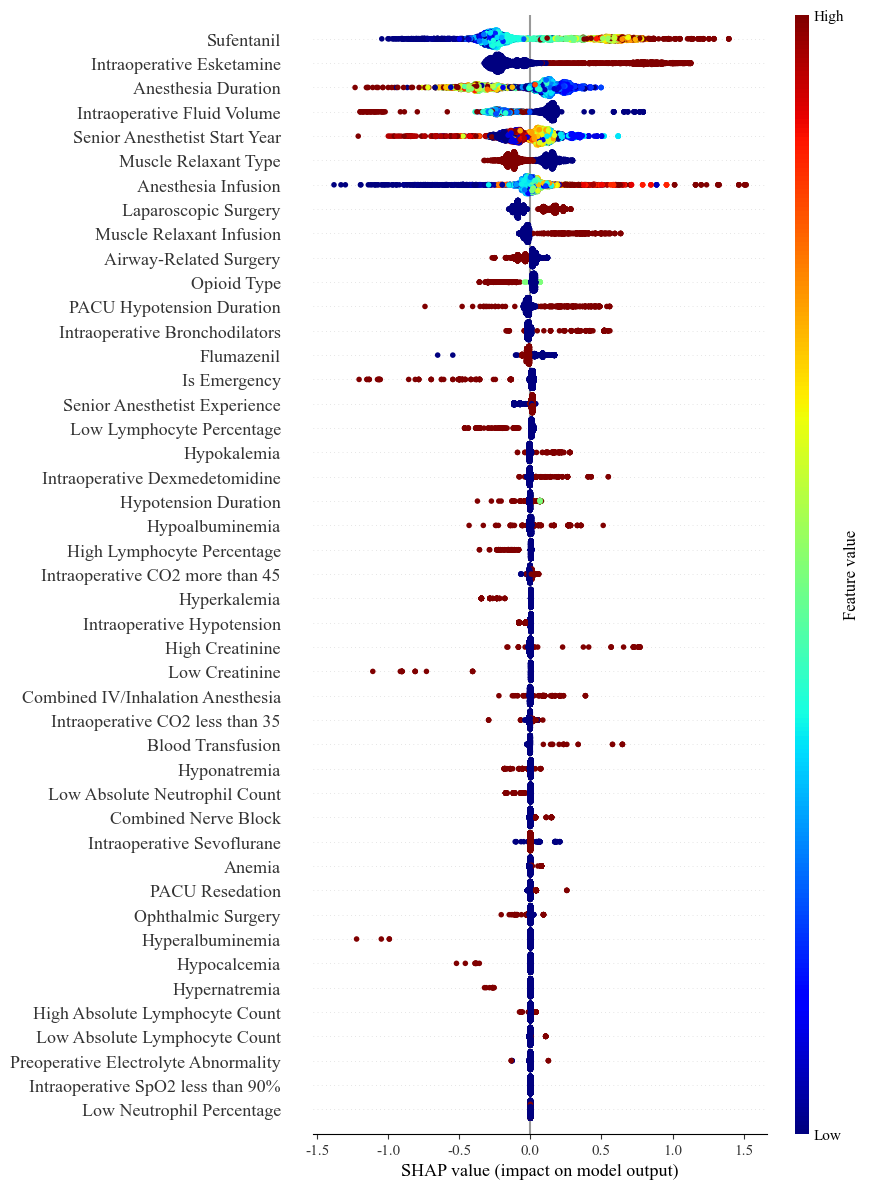

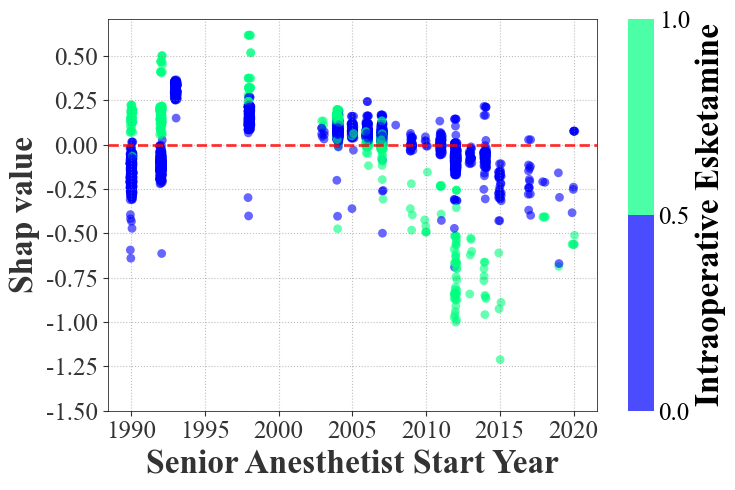

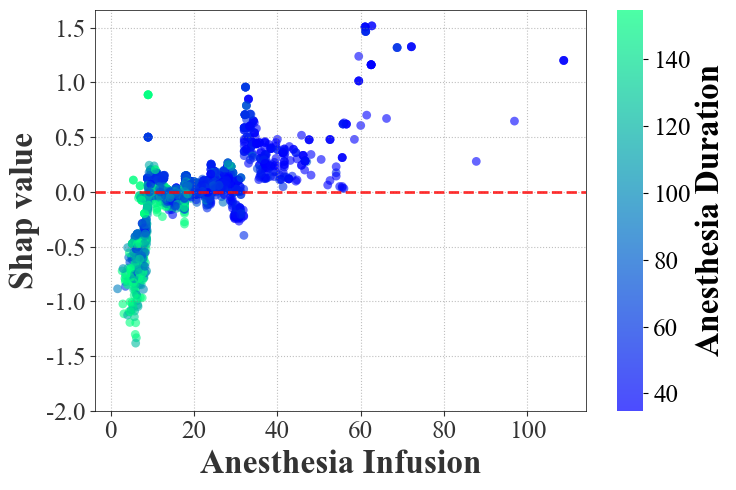

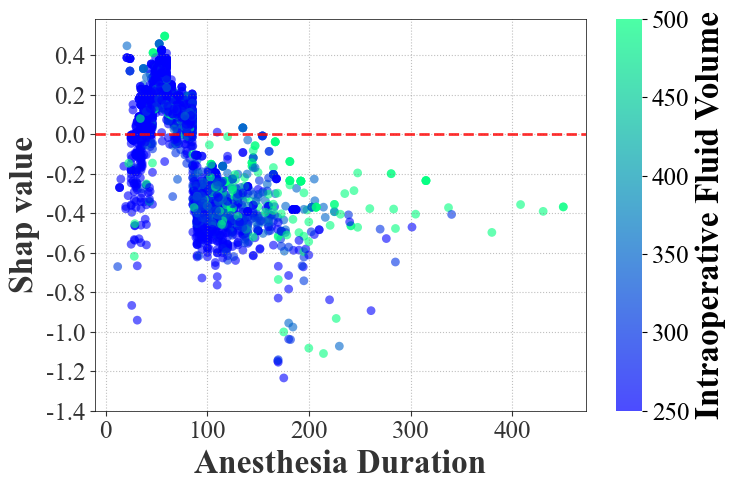

(3677, 45)
主效应SHAP值计算完成。

正在计算SHAP交互效应值 (基于X_test)...


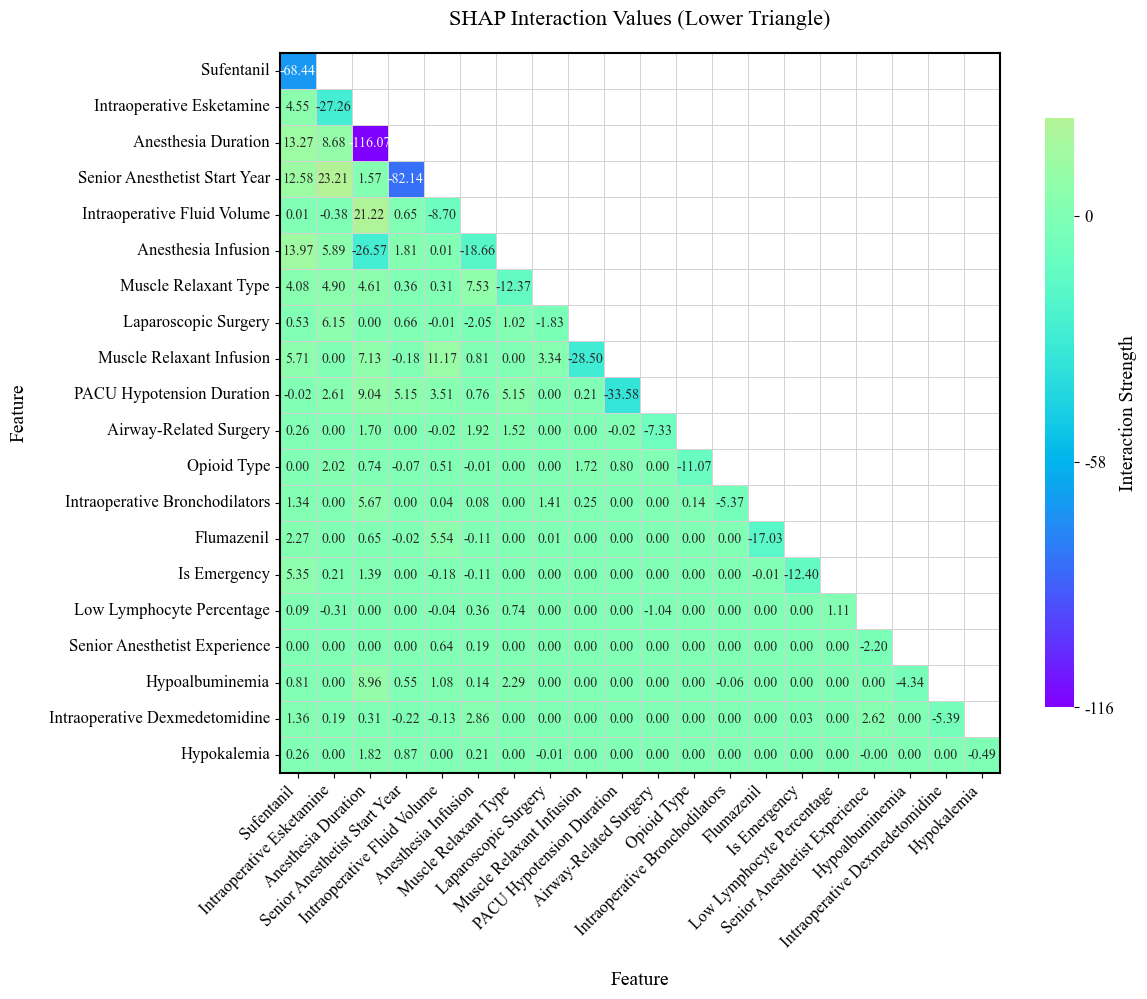

<class 'numpy.ndarray'>


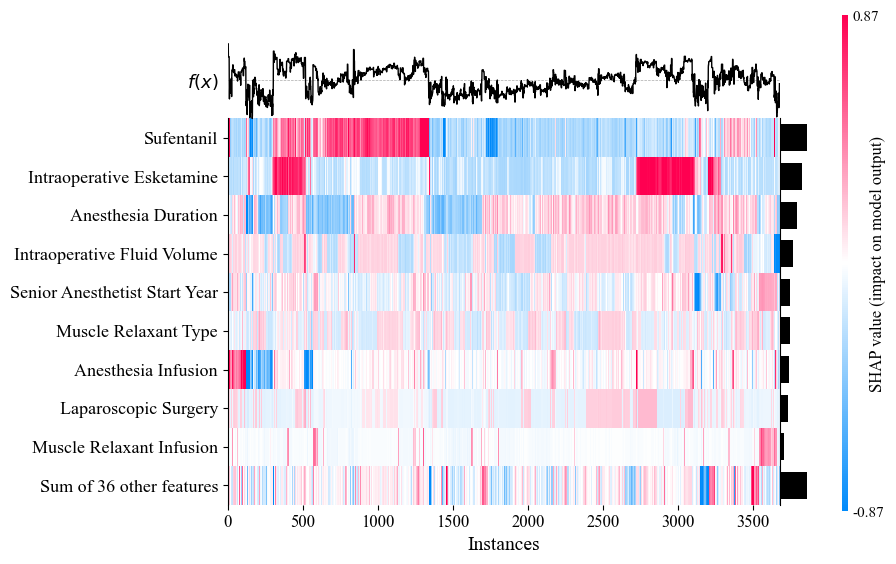

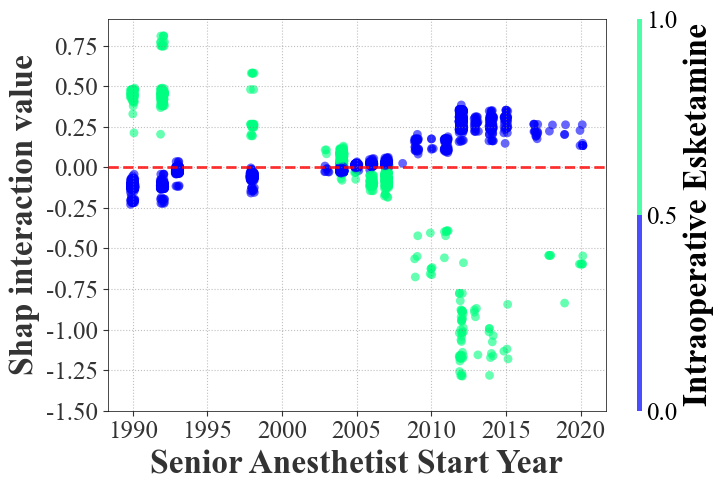

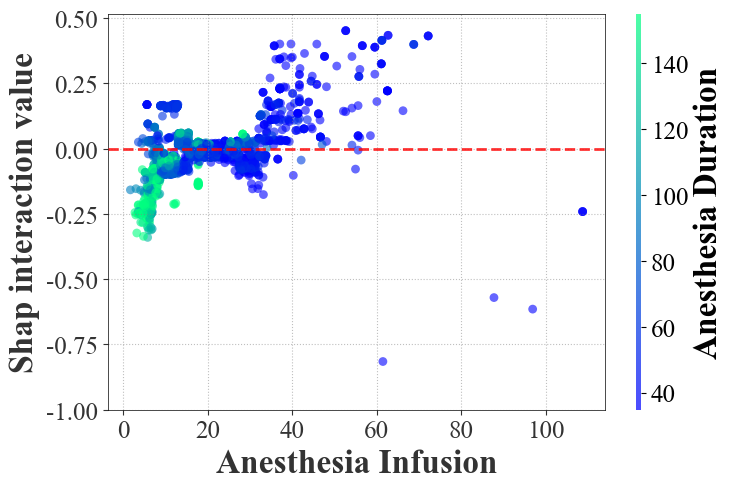

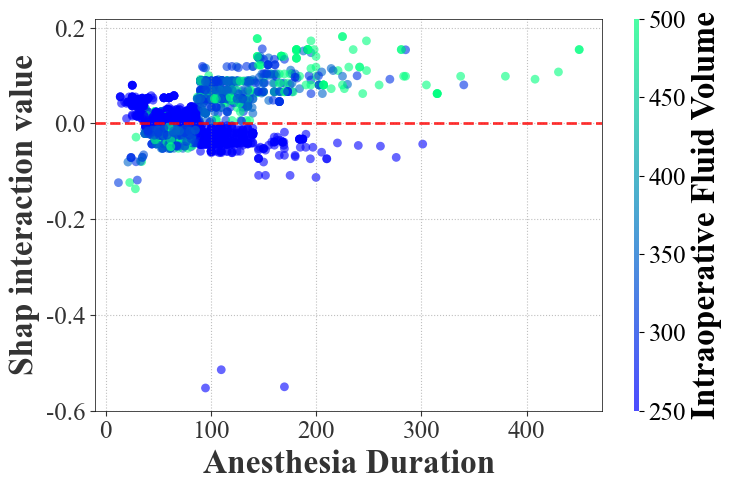

In [2]:
podaa.shap_Importance_Features()

In [3]:
pip install shap -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


f1:  0.7814569536423841
acc： 0.8981481481481481
pcc： 0.6941176470588235
rcc： 0.8939393939393939


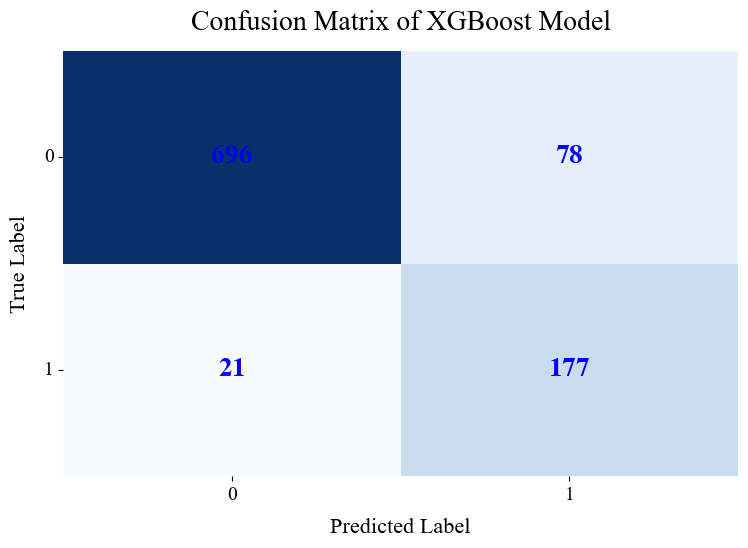

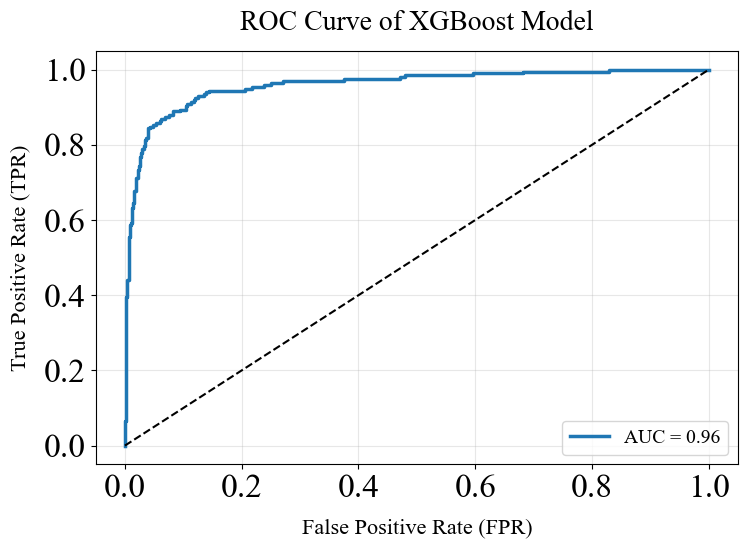

In [5]:
podaa.XGBoost_Model()

In [8]:
print(len(features))

46


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 7)
print(len(y_train[y_train == 1]))

491


In [8]:
from PODAA_Model import PODAA
podaa = PODAA(X_train,X_test,y_train,y_test,features)


Imported featurewiz_polars 0.3.0. Use the following syntax:
 >> from featurewiz_polars import FeatureWiz, FeatureWiz_Model
    


In [9]:
pip install matplotlib  -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install seaborn -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


f1:  0.421792618629174
acc： 0.661522633744856
pcc： 0.32345013477088946
rcc： 0.6060606060606061 



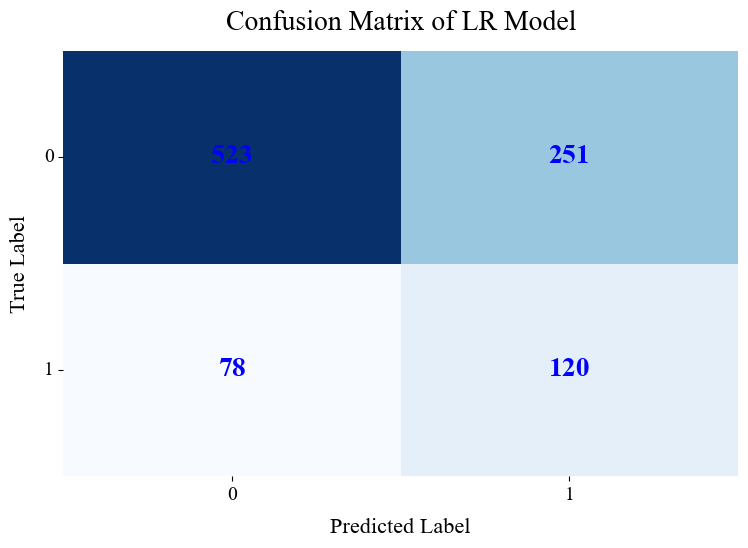

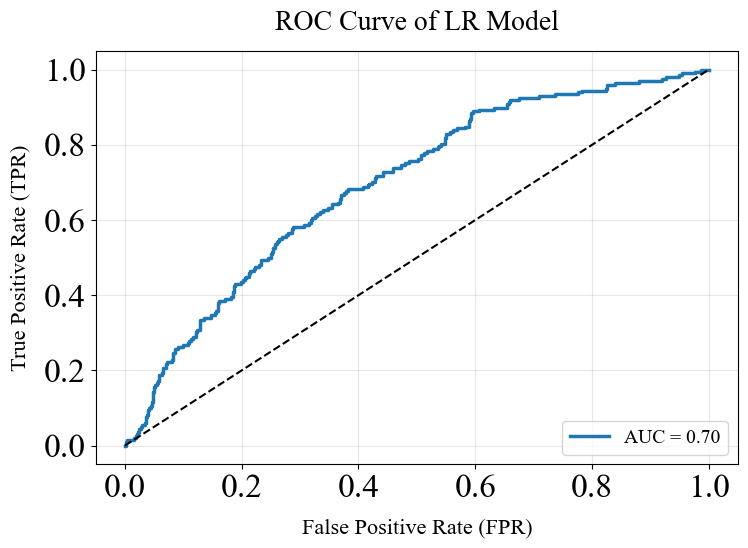

In [4]:
podaa.LR()

f1:  0.9116945107398569
acc： 0.9619341563786008
pcc： 0.8642533936651584
rcc： 0.9646464646464646 



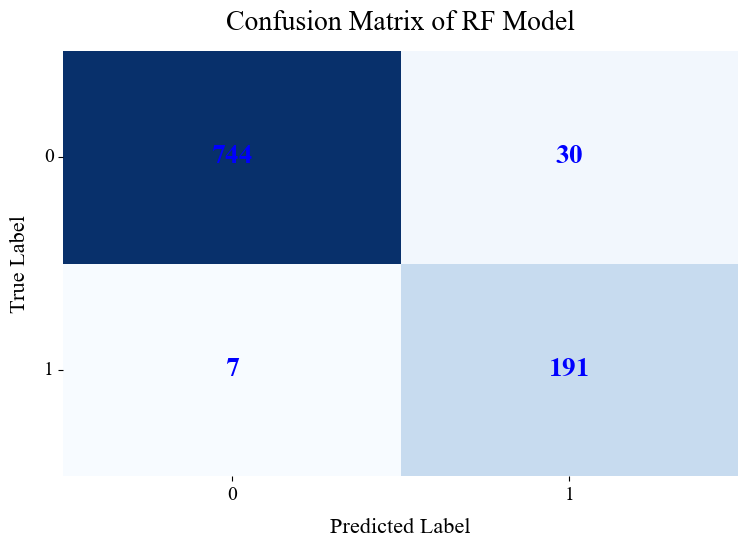

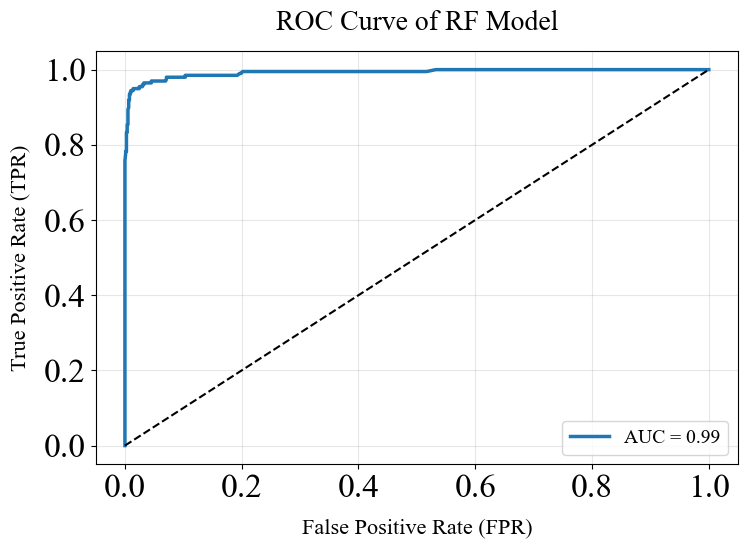

In [3]:
podaa.RF_Model()

f1:  0.8816705336426914
acc： 0.9475308641975309
pcc： 0.8154506437768241
rcc： 0.9595959595959596 



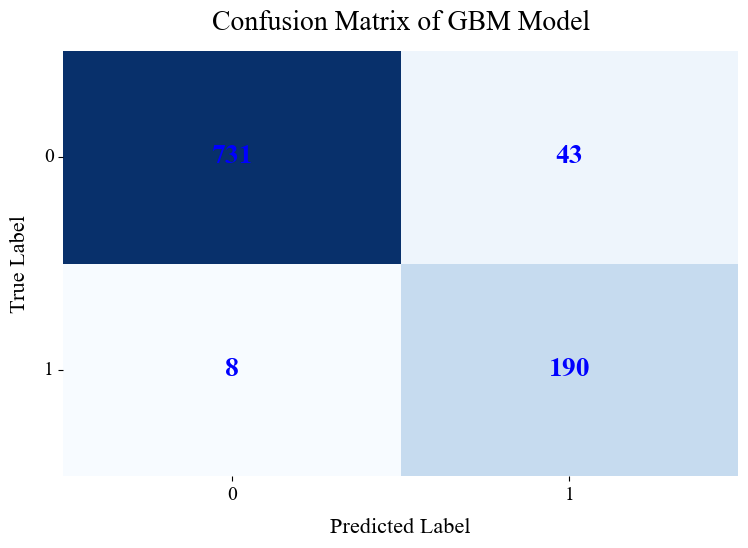

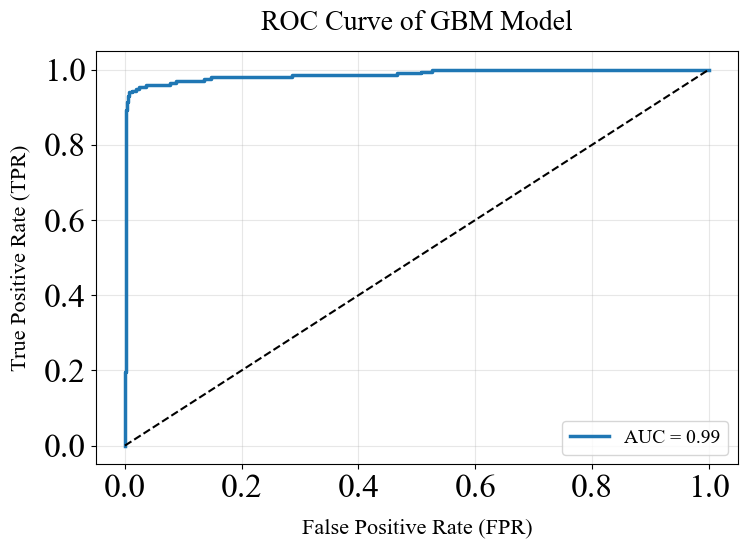

In [6]:
podaa.GBM_Model()

In [15]:
pip install xgboost -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


f1:  0.8567961165048543
acc： 0.8503487634749525
pcc： 0.8209302325581396
rcc： 0.8959390862944162


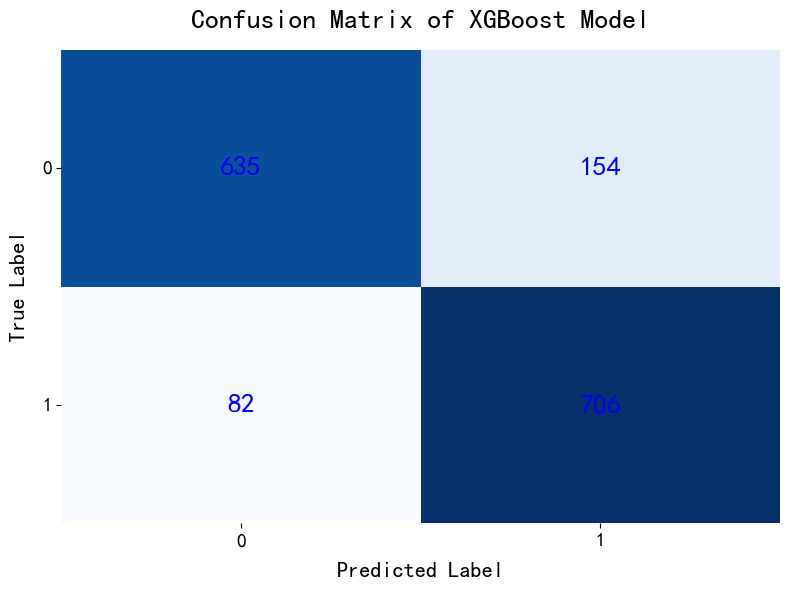

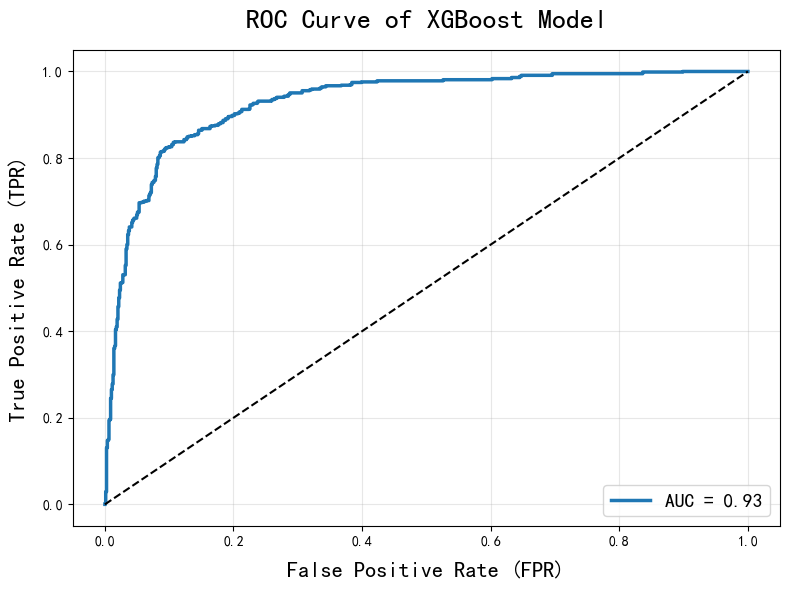

In [5]:
podaa.XGBoost_Model()

f1:  0.8552709946396665
acc： 0.8459099556119214
pcc： 0.8058361391694725
rcc： 0.9111675126903553


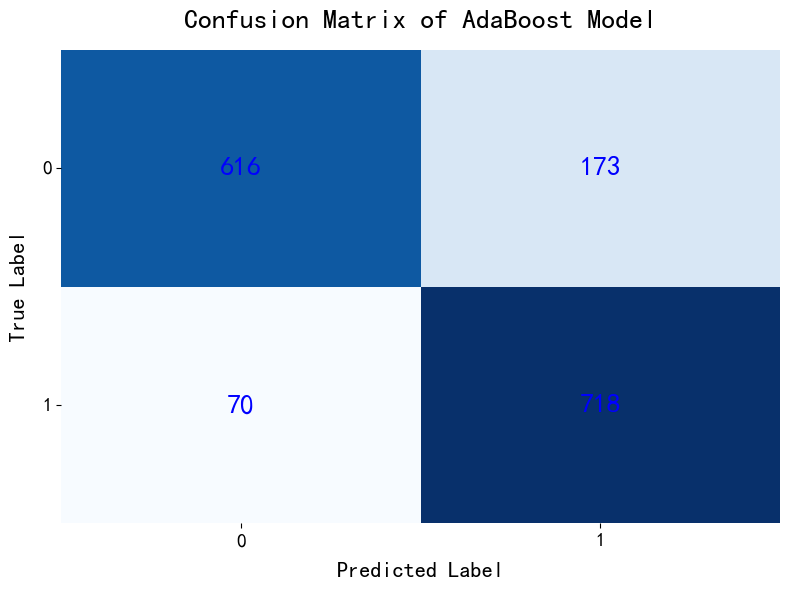

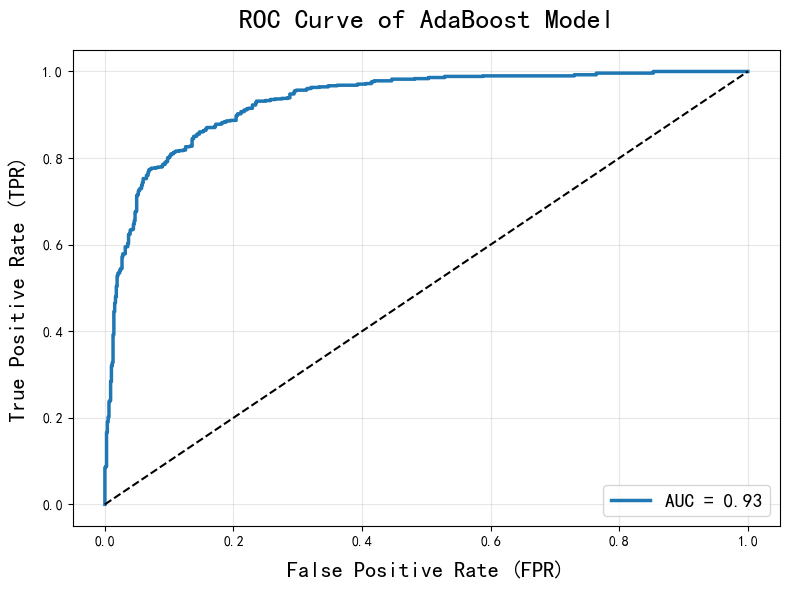

In [6]:
podaa.AdaBoost_Model()

f1:  0.8812572759022119
acc： 0.8706404565630945
pcc： 0.8139784946236559
rcc： 0.9606598984771574


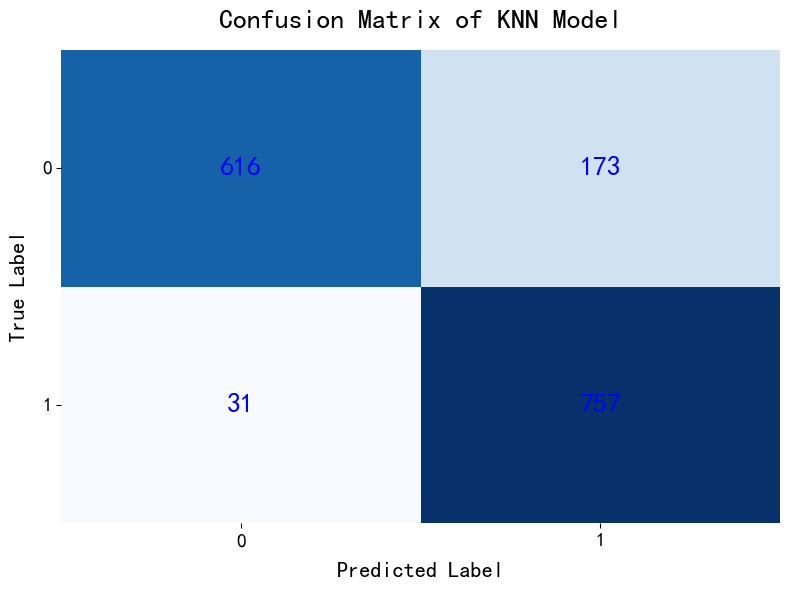

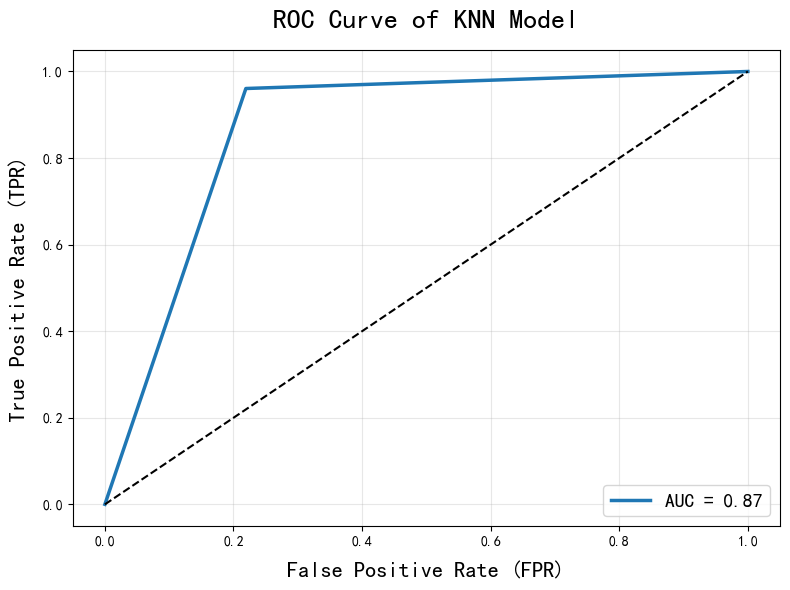

In [7]:
podaa.KNN_Model()

f1:  0.70125
acc： 0.6968928344958782
pcc： 0.6908866995073891
rcc： 0.7119289340101523


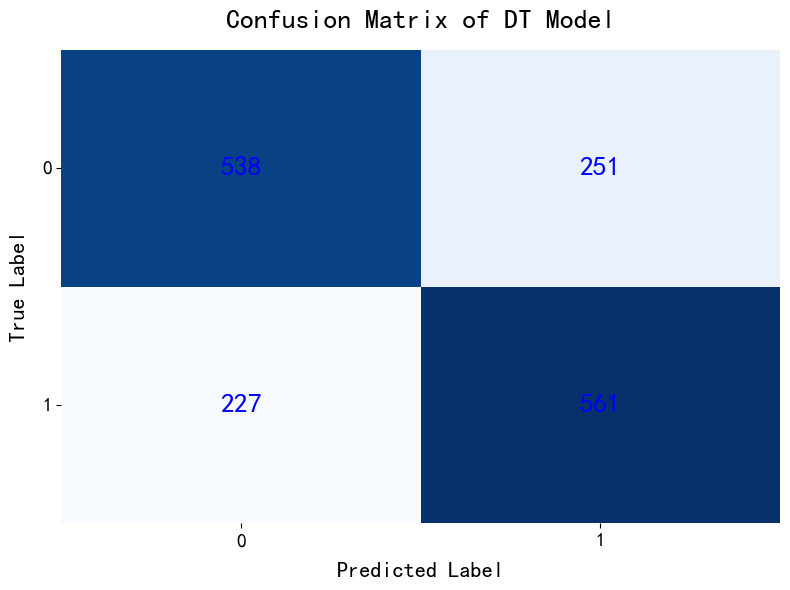

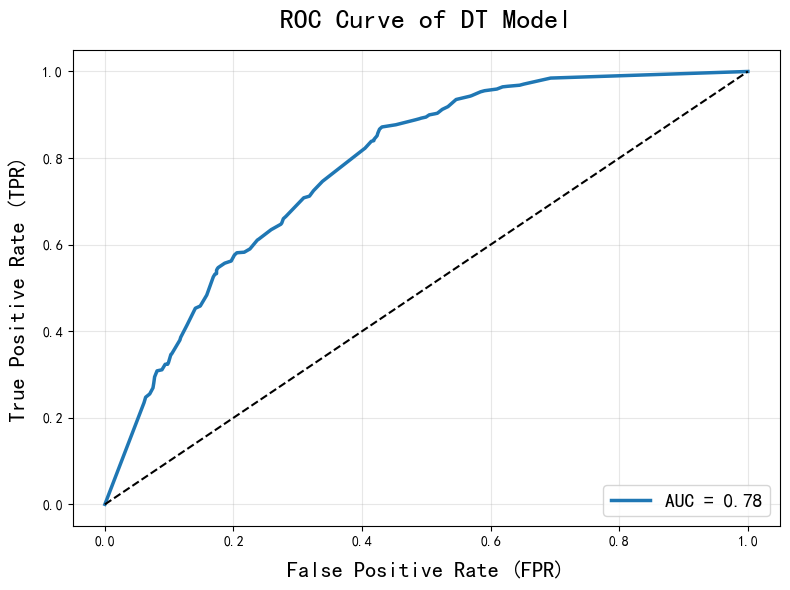

In [8]:
podaa.DT_Model()  

f1:  0.6053299492385786
acc： 0.605580215599239
pcc： 0.6053299492385786
rcc： 0.6053299492385786


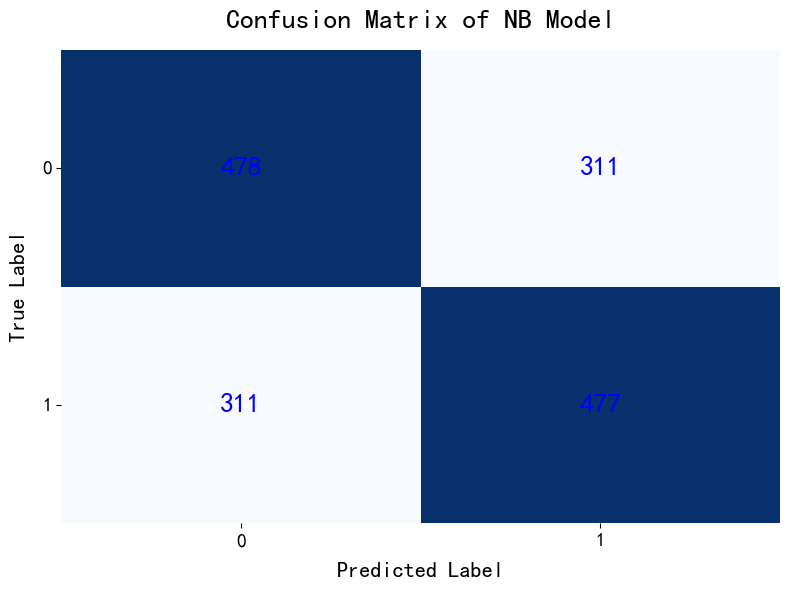

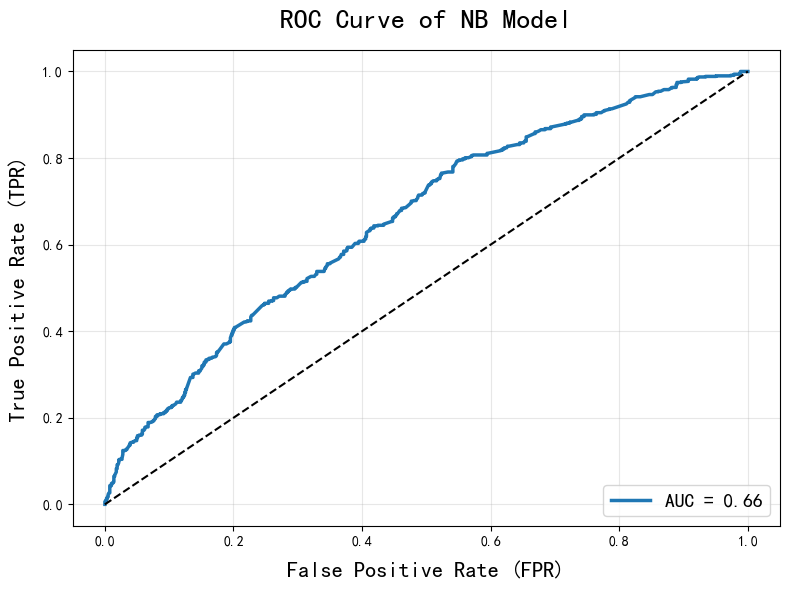

In [9]:
podaa.NB_Model()

f1:  0.6483375959079284
acc： 0.6512365250475587
pcc： 0.6533505154639175
rcc： 0.6434010152284264


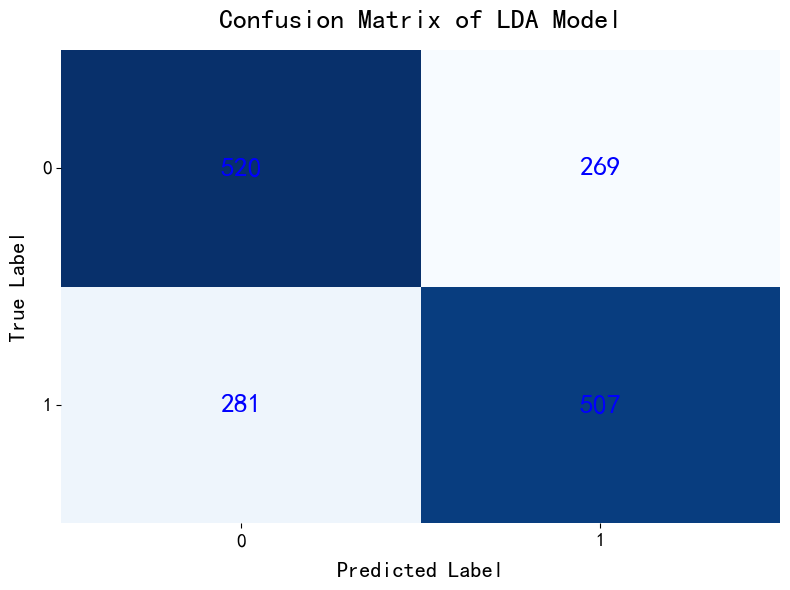

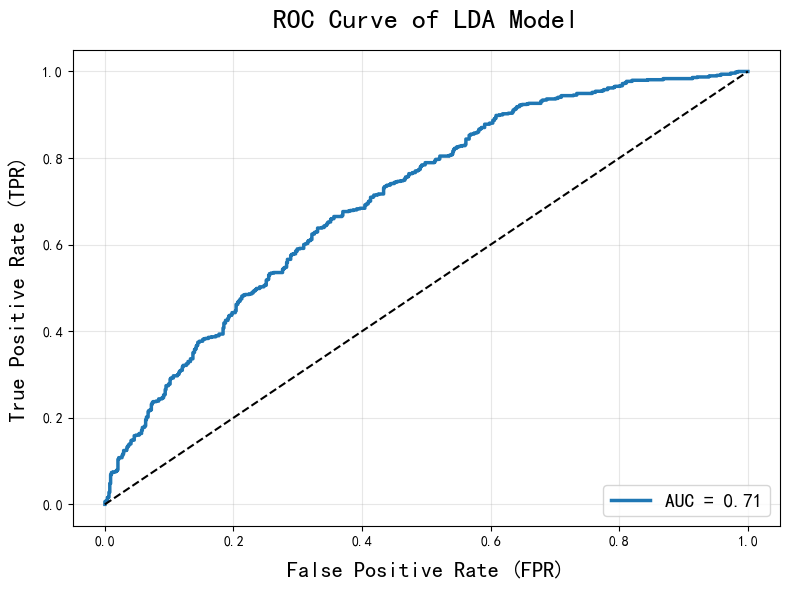

In [10]:
podaa.LDA_Model()

In [22]:
pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [23]:
print(len(y))

569


In [24]:
pip install boruta  -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [55]:
pip install git+https://github.com/AutoViML/featurewiz_polars.git

  Cloning https://github.com/AutoViML/featurewiz_polars.git to c:\users\xiaxq\appdata\local\temp\pip-req-build-lofkloop
  Resolved https://github.com/AutoViML/featurewiz_polars.git to commit 7b52501aa540a32d07f074514bcec6624f801ba8
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
INFO: pip is looking at multiple versions of featurewiz-polars to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/AutoViML/featurewiz_polars.git 'C:\Users\xiaxq\AppData\Local\Temp\pip-req-build-lofkloop'
ERROR: Could not find a version that satisfies the requirement polars>=1.23.0 (from featurewiz-polars) (from versions: none)
ERROR: No matching distribution found for polars>=1.23.0


In [57]:
pip install polars>=1.23.0 -i https://pypi.tuna.tsinghua.edu.cn/simple

Note: you may need to restart the kernel to use updated packages.


In [5]:
conda list

# packages in environment at D:\Anaconda\envs\PODAA:
#
# Name                    Version                   Build  Channel
anyio                     4.8.0              pyhd8ed1ab_0    conda-forge
argon2-cffi               23.1.0             pyhd8ed1ab_1    conda-forge
argon2-cffi-bindings      21.2.0          py312h4389bb4_5    conda-forge
arrow                     1.3.0              pyhd8ed1ab_1    conda-forge
asttokens                 3.0.0              pyhd8ed1ab_1    conda-forge
async-lru                 2.0.4              pyhd8ed1ab_1    conda-forge
attrs                     25.1.0             pyh71513ae_0    conda-forge
babel                     2.17.0             pyhd8ed1ab_0    conda-forge
beautifulsoup4            4.13.3             pyha770c72_0    conda-forge
bleach                    6.2.0              pyh29332c3_4    conda-forge
bleach-with-css           6.2.0                h82add2a_4    conda-forge
boruta                    0.4.3                    pypi_0    pypi
brotli-py

In [7]:
pip install featurewiz_polars -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
     - -------------------------------------- 0.5/15.5 MB 2.8 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/15.5 MB 2.1 MB/s eta 0:00:08
     -- ------------------------------------- 1.0/15.5 MB 1.9 MB/s eta 0:00:08
     ---- ----------------------------------- 1.6/15.5 MB 1.8 MB/s eta 0:00:08
     ---- ----------------------------------- 1.8/15.5 MB 1.8 MB/s eta 0:00:08
     ----- ---------------------------------- 2.1/15.5 MB 1.8 MB/s eta 0:00:08
     ------ --------------------------------- 2.6/15.5 MB 1.8 MB/s eta 0:00:08
     ------- -------------------------------- 2.9/15.5 MB 1.7 MB/s eta 0:00:08
     -------- ------------------------------- 3.4/15.5 MB 1.7 MB/s eta 0:00:07
     --------- ------------------------------ 3.7/15.5 MB 1.7 MB/s eta 0:00:07
     ---------- ----------------------------- 3.9/15.5 MB 1.7 MB/s eta 0:00:0

In [7]:
from featurewiz_polars import polars_train_test_split

In [2]:
import polars as pl
df = pl.read_csv('fin_data/怀化数据_完整_填充缺失值.csv', null_values=['NULL','NA'], try_parse_dates=True,
            infer_schema_length=10000, ignore_errors=True)
# Before we do feature selection we always need to make sure we split the data #######
target = '苏醒延迟60'
predictors = [x for x in df.columns if x not in ['苏醒延迟60','转出延迟']]

X = df[predictors]
y = df[target] 
X_train, X_test, y_train, y_test = polars_train_test_split(X, y, test_size=0.2, random_state=42)
from featurewiz_polars import FeatureWiz

# Initialize FeatureWiz for classification
wiz = FeatureWiz(model_type="Classification", estimator=None,
        corr_limit=0.7, category_encoders='onehot', classic=True, verbose=0)

# Fit and transform the training data
X_transformed, y_transformed = wiz.fit_transform(X_train, y_train)

# Transform the test data
X_test_transformed = wiz.transform(X_test)

# Transform the test target variable
y_test_transformed = wiz.y_encoder.transform(y_test)

ColumnNotFoundError: "苏醒延迟60" not found

In [11]:
# View results
print("Selected Features:")
print(wiz.selected_features)
# Example Output: ['col1', 'col2', 'category_A', 'category_B']

print("\nTransformed DataFrame head:")
print(X_transformed.head())
# Example Output: Polars DataFrame with only the selected features

Selected Features:
['麻醉时长', '麻醉上级工作时间几年多', '麻醉输液mlkgh', '钾离子偏低', '腔镜手术', '肌酐偏高', '钠离子偏高', '麻醉上级工作大于10年1是', '顺阿1维库0', '钙离子偏低', '舒芬1阿芬2芬太尼3', '舒芬太尼ugkg', '粒细胞%偏低', '钾离子偏高', '静吸复合麻醉1TIV10', '肌酐偏低', '粒细胞绝对值偏低', '钠离子偏低', '术中输液量ml', '术中艾司氯胺酮1是', '泵注肌松药物1是', '眼科手术', '淋巴细胞绝对值偏低', '淋巴细胞%偏低', '白蛋白偏低', '术前电解质异常', '白蛋白偏高', '气道相关手术', '淋巴细胞绝对值偏高', '淋巴细胞%偏高', '氟马纳洛酮', '术中支气管扩张药物', '术中有SPO2小于90是1', '术中低血压持续时间min', '是否急诊1是', '术中使用七氟烷', '是否输血', '术中使用右美1是', '术中1有CO2小于35', '是否复合神经阻滞1是', '术中1有CO2大于45', '是否贫血', 'PACU低血压持续时间', 'PACU再次镇静', '上级开始工作年限', '术中发生低血压1是']

Transformed DataFrame head:
shape: (5, 46)
┌──────────┬──────────────────┬───────────────┬────────────┬───┬──────────────────┬──────────────┬──────────────────┬─────────────────┐
│ 麻醉时长 ┆ 麻醉上级工作时间 ┆ 麻醉输液mlkgh ┆ 钾离子偏低 ┆ … ┆ PACU低血压持续时 ┆ PACU再次镇静 ┆ 上级开始工作年限 ┆ 术中发生低血压1 │
│ ---      ┆ 几年多           ┆ ---           ┆ ---        ┆   ┆ 间               ┆ ---          ┆ ---              ┆ 是              │
│ f64      ┆ ---              ┆ f64           ┆ f64 